In [1]:
"""
Analyse de la Malnutrition dans le Monde - Données FAO
=======================================================
Projet réalisé dans le cadre de la formation OpenClassrooms
"Réalisez une étude de santé publique avec R ou Python"
 
Objectifs :
    - Calculer la proportion mondiale de personnes en état de sous-nutrition (2017)
    - Estimer le nombre théorique de personnes pouvant être nourries
      à partir de la disponibilité alimentaire mondiale et végétale
    - Analyser l'utilisation de la disponibilité intérieure
      (alimentation animale, pertes, alimentation humaine)
    - Identifier les pays les plus touchés par la sous-alimentation
    - Analyser la distribution de l'aide alimentaire internationale
 
Source des données : FAO (Food and Agriculture Organization of the United Nations)
Auteur              : Yann
Date                : 2024
"""
# =============================================================================
# 0. IMPORTS ET CONFIGURATION
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

In [2]:
# =============================================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =============================================================================
def load_sous_nutrition(filepath: str = "sous_nutrition.csv") -> pd.DataFrame:
    """
    Charge et restructure les données de sous-nutrition de la FAO.
 
    Le fichier source contient des triplets (Zone, Année, Valeur) en format long.
    Cette fonction le pivote en format large (une colonne par période).
 
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV source.
 
    Returns
    -------
    pd.DataFrame
        DataFrame indexé par 'Zone', avec une colonne par période triannuelle
        (ex: '2012-2014', '2013-2015', ..., '2017-2019').
        Les valeurs représentent le nombre de personnes sous-alimentées
        en millions d'individus.
    """
    df = pd.read_csv(filepath)
    # La colonne 'Valeur' peut contenir des marqueurs FAO ('<' ou 'n.d.')
    # → coercion silencieuse en NaN
    df["Valeur"] = pd.to_numeric(df["Valeur"], errors="coerce")
    df = df.pivot_table(values="Valeur", index="Zone", columns="Année")
    return df
 
 
def load_population(filepath: str = "population.csv") -> pd.DataFrame:
    """
    Charge et restructure les données de population par pays.
 
    Les valeurs brutes sont en milliers d'individus ; elles sont converties
    en millions pour homogénéité avec les autres indicateurs FAO.
 
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV source.
 
    Returns
    -------
    pd.DataFrame
        DataFrame indexé par 'Zone', colonnes = années (int),
        valeurs en millions d'habitants (arrondi à 1 décimale).
    """
    df = pd.read_csv(filepath)
    df["Valeur"] = round(df["Valeur"] / 1_000, 1)  # milliers → millions
    df = df.pivot_table(values="Valeur", index="Zone", columns="Année")
    return df
 
 
def load_disponibilite_alimentaire(filepath: str = "dispo_alimentaire.csv") -> pd.DataFrame:
    """
    Charge les données de disponibilité alimentaire de la FAO.
 
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV source.
 
    Returns
    -------
    pd.DataFrame
        DataFrame brut contenant notamment les colonnes :
        'Zone', 'Origine', 'Disponibilité alimentaire (Kcal/personne/jour)',
        'Disponibilité intérieure', ainsi que les colonnes d'utilisation
        (alimentation animale, pertes, nourriture humaine).
    """
    return pd.read_csv(filepath)
 
 
def load_aide_alimentaire(filepath: str = "aide_alimentaire.csv") -> pd.DataFrame:
    """
    Charge et restructure les données d'aide alimentaire internationale.
 
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV source.
 
    Returns
    -------
    pd.DataFrame
        DataFrame indexé par 'Pays bénéficiaire', colonnes = années,
        valeurs = montant de l'aide reçue.
    """
    df = pd.read_csv(filepath)
    df = df.pivot_table(values="Valeur", index="Pays bénéficiaire", columns="Année")
    df = df.reset_index()
    return df

In [3]:
# --- Chargement effectif ---
sous_nutrition = load_sous_nutrition()
population = load_population()
dispo_alimentaire = load_disponibilite_alimentaire()
aide_alimentaire = load_aide_alimentaire()
 
print("✅ Données chargées avec succès.")
print(f"   • Sous-nutrition    : {sous_nutrition.shape[0]} pays, {sous_nutrition.shape[1]} périodes")
print(f"   • Population        : {population.shape[0]} pays, {population.shape[1]} années")
print(f"   • Dispo alimentaire : {dispo_alimentaire.shape[0]} lignes")
print(f"   • Aide alimentaire  : {aide_alimentaire.shape[0]} pays bénéficiaires\n")

✅ Données chargées avec succès.
   • Sous-nutrition    : 87 pays, 6 périodes
   • Population        : 236 pays, 6 années
   • Dispo alimentaire : 15605 lignes
   • Aide alimentaire  : 76 pays bénéficiaires



In [4]:
# =============================================================================
# 2. INDICATEUR GLOBAL — TAUX DE SOUS-NUTRITION (2017-2019 / 2018)
# =============================================================================
 
 
def calculer_taux_sous_nutrition(
    df_sous_nutrition: pd.DataFrame,
    df_population: pd.DataFrame,
    periode_sn: str = "2017-2019",
    annee_pop: int = 2018,
) -> float:
    """
    Calcule la proportion mondiale de personnes en état de sous-nutrition.
 
    La FAO publie la sous-nutrition sur des moyennes glissantes de 3 ans.
    On utilise la période '2017-2019' rapportée à la population 2018
    (année centrale de la période).
 
    Parameters
    ----------
    df_sous_nutrition : pd.DataFrame
        Données de sous-nutrition (millions de personnes) par pays et période.
    df_population : pd.DataFrame
        Données de population (millions) par pays et année.
    periode_sn : str
        Colonne de période à utiliser dans df_sous_nutrition.
    annee_pop : int
        Année de référence à utiliser dans df_population.
 
    Returns
    -------
    float
        Part de la population mondiale sous-alimentée, en pourcentage (%).
    """
    total_sous_nutrition = df_sous_nutrition[periode_sn].sum()
    total_population = df_population[annee_pop].sum()
    taux = round((total_sous_nutrition / total_population) * 100, 1)
    return taux
 
 
taux_sn_mondial = calculer_taux_sous_nutrition(sous_nutrition, population)
print("=" * 60)
print("RÉSULTAT 1 — Taux de sous-nutrition mondial (réf. 2018)")
print("=" * 60)
print(f"  → {taux_sn_mondial} % de la population mondiale est sous-alimentée\n")

RÉSULTAT 1 — Taux de sous-nutrition mondial (réf. 2018)
  → 7.1 % de la population mondiale est sous-alimentée



In [5]:
# =============================================================================
# 3. DISPONIBILITÉ ALIMENTAIRE — CAPACITÉ THÉORIQUE DE NOURRISSAGE
# =============================================================================
 
 
def construire_dataset_disponibilite(
    df_dispo: pd.DataFrame,
    df_population: pd.DataFrame,
    annee_pop: int = 2018,
) -> pd.DataFrame:
    """
    Fusionne la disponibilité alimentaire avec la population pour calculer
    la disponibilité totale (Kcal globales par pays).
 
    La colonne 'dispo_totale' représente la disponibilité alimentaire agrégée
    d'un pays : kcal/personne/jour × population (millions) × 365.
    Exprimée en Kcal × 10^6 × 365 (soit Kcal-millions-année).
 
    Parameters
    ----------
    df_dispo : pd.DataFrame
        Données de disponibilité alimentaire FAO.
    df_population : pd.DataFrame
        Données de population par pays et année.
    annee_pop : int
        Année de référence pour la population.
 
    Returns
    -------
    pd.DataFrame
        Dataset enrichi avec les colonnes de population et 'dispo_totale'.
    """
    pop_ref = df_population[[annee_pop]].rename(columns={annee_pop: "population"})
    merged = pd.merge(df_dispo, pop_ref, on="Zone", how="inner")
    merged["dispo_totale"] = (
        merged["Disponibilité alimentaire (Kcal/personne/jour)"] * merged["population"]
    )
    return merged
 
 
def calculer_capacite_nourrissage(
    df_merged: pd.DataFrame,
    kcal_par_personne_par_jour: float = 2_500,
    origine: str = None,
) -> float:
    """
    Estime le nombre théorique de personnes pouvant être nourries
    à partir de la disponibilité alimentaire totale.
 
    Hypothèse : besoin calorique moyen de 2 500 Kcal/personne/jour.
    La disponibilité totale est en Kcal × millions d'habitants,
    le résultat est donc directement en milliards de personnes.
 
    Parameters
    ----------
    df_merged : pd.DataFrame
        Dataset avec la colonne 'dispo_totale' et éventuellement 'Origine'.
    kcal_par_personne_par_jour : float
        Seuil calorique journalier moyen utilisé pour le calcul.
    origine : str or None
        Si spécifié ('vegetale', 'animale'), filtre sur cette origine.
        Si None, prend toutes les origines.
 
    Returns
    -------
    float
        Nombre théorique de personnes nourries, en milliards.
    """
    if origine is not None:
        df_merged = df_merged[df_merged["Origine"] == origine]
 
    dispo_totale = df_merged["dispo_totale"].sum()
    # dispo_totale est en Kcal × millions de personnes
    # → diviser par kcal/personne/jour × 365 pour obtenir des millions de personnes
    # → diviser par 1 000 pour obtenir des milliards
    capacite_millions = dispo_totale / kcal_par_personne_par_jour
    capacite_milliards = round(capacite_millions / 1_000, 1)
    return capacite_milliards
 
 
dataset_dispo = construire_dataset_disponibilite(dispo_alimentaire, population)
 
capacite_mondiale = calculer_capacite_nourrissage(dataset_dispo)
capacite_vegetale = calculer_capacite_nourrissage(dataset_dispo, origine="vegetale")
 
print("=" * 60)
print("RÉSULTAT 2 — Capacité théorique de nourrissage")
print("=" * 60)
print(f"  → Disponibilité totale (toutes origines) : {capacite_mondiale} milliards de personnes")
print(f"  → Disponibilité végétale uniquement       : {capacite_vegetale} milliards de personnes\n")

RÉSULTAT 2 — Capacité théorique de nourrissage
  → Disponibilité totale (toutes origines) : 8.5 milliards de personnes
  → Disponibilité végétale uniquement       : 7.0 milliards de personnes



RÉSULTAT 3 — Utilisation de la disponibilité intérieure
  → Alimentation animale : 13.2 %
  → Pertes               : 4.6 %
  → Alimentation humaine : 49.4 %



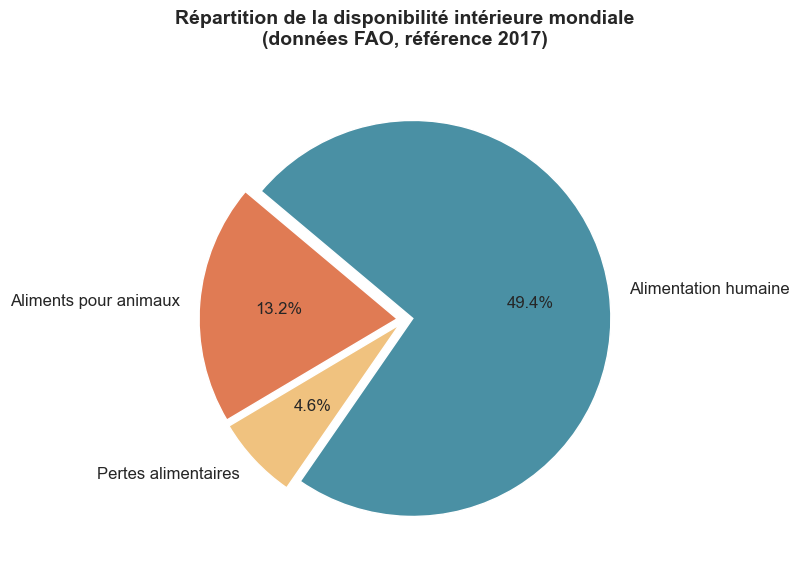

In [9]:
# =============================================================================
# 4. UTILISATION DE LA DISPONIBILITÉ INTÉRIEURE
# =============================================================================
 
 
def analyser_disponibilite_interieure(df_merged: pd.DataFrame) -> dict:
    """
    Calcule la répartition de la disponibilité intérieure mondiale
    entre alimentation animale, pertes et alimentation humaine.
 
    Parameters
    ----------
    df_merged : pd.DataFrame
        Dataset fusionné avec les colonnes FAO d'utilisation :
        'Disponibilité intérieure', 'Alimentation animale', 'Pertes',
        'Nourriture'.
 
    Returns
    -------
    dict
        Dictionnaire avec les parts en pourcentage pour chaque usage :
        'alimentation_animale', 'pertes', 'alimentation_humaine'.
    """
    dispo_interieure_totale = df_merged["Disponibilité intérieure"].sum()
 
    part_animale = round(
        (df_merged["Aliments pour animaux"].sum() / dispo_interieure_totale) * 100, 1
    )
    part_pertes = round(
        (df_merged["Pertes"].sum() / dispo_interieure_totale) * 100, 1
    )
    part_humaine = round(
        (df_merged["Nourriture"].sum() / dispo_interieure_totale) * 100, 1
    )
 
    return {
        "Aliments pour animaux": part_animale,
        "pertes": part_pertes,
        "alimentation_humaine": part_humaine,
    }
 
 
repartition_interieure = analyser_disponibilite_interieure(dataset_dispo)
 
print("=" * 60)
print("RÉSULTAT 3 — Utilisation de la disponibilité intérieure")
print("=" * 60)
print(f"  → Alimentation animale : {repartition_interieure['Aliments pour animaux']} %")
print(f"  → Pertes               : {repartition_interieure['pertes']} %")
print(f"  → Alimentation humaine : {repartition_interieure['alimentation_humaine']} %\n")
 
# Visualisation — Camembert de répartition
labels = ["Aliments pour animaux", "Pertes alimentaires", "Alimentation humaine"]
valeurs = [
    repartition_interieure["Aliments pour animaux"],
    repartition_interieure["pertes"],
    repartition_interieure["alimentation_humaine"]
]
couleurs = ["#E07B54", "#F0C27F", "#4A90A4"]
explode = (0.04, 0.04, 0.04)
 
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    valeurs,
    labels=labels,
    colors=couleurs,
   autopct=lambda p: '{:.1f}%'.format(p * sum(valeurs) / 100),
    startangle=140,
    explode=explode,
    textprops={"fontsize": 12},
)
ax.set_title(
    "Répartition de la disponibilité intérieure mondiale\n(données FAO, référence 2017)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.savefig("repartition_disponibilite_interieure.png", dpi=150)
plt.show()

RÉSULTAT 4 — Top 10 pays les plus touchés par la sous-alimentation
                                      Zone  sous_nutrition_M  population_M  part_pct
                                     Haïti               5.3          11.0      48.2
République populaire démocratique de Corée              12.0          25.4      47.2
                                Madagascar              10.5          25.6      41.0
                                   Libéria               1.8           4.7      38.3
                                   Lesotho               0.8           2.1      38.1
                                     Tchad               5.7          15.0      38.0
                                    Rwanda               4.2          12.0      35.0
                               Timor-Leste               0.4           1.2      33.3
                                Mozambique               9.4          28.6      32.9
                               Afghanistan              10.5          36.3      28.

C:\Users\yanne\AppData\Local\Temp\ipykernel_14632\318425716.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


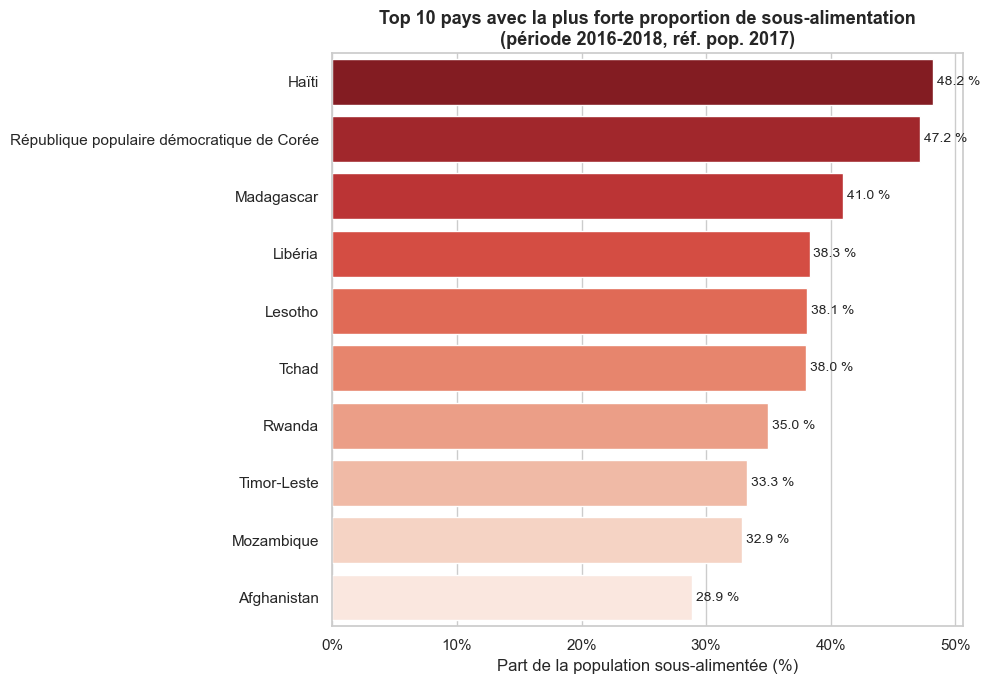

In [10]:
# =============================================================================
# 5. PAYS LES PLUS TOUCHÉS PAR LA SOUS-ALIMENTATION
# =============================================================================
 
 
def identifier_pays_les_plus_touches(
    df_sous_nutrition: pd.DataFrame,
    df_population: pd.DataFrame,
    periode_sn: str = "2016-2018",
    annee_pop: int = 2017,
    top_n: int = 10,
) -> pd.DataFrame:
    """
    Identifie les pays pour lesquels la part de population sous-alimentée
    est la plus élevée sur une période donnée.
 
    Parameters
    ----------
    df_sous_nutrition : pd.DataFrame
        Données de sous-nutrition (millions) par pays.
    df_population : pd.DataFrame
        Données de population (millions) par pays et année.
    periode_sn : str
        Période triannuelle FAO à utiliser pour la sous-nutrition.
    annee_pop : int
        Année de référence pour la population (idéalement centrale à la période).
    top_n : int
        Nombre de pays à retourner.
 
    Returns
    -------
    pd.DataFrame
        DataFrame des `top_n` pays avec colonnes :
        'Zone', 'sous_nutrition_M', 'population_M', 'part_pct'.
    """
    pop_ref = df_population[[annee_pop]].rename(columns={annee_pop: "population_M"})
    sn_ref = df_sous_nutrition[[periode_sn]].rename(
        columns={periode_sn: "sous_nutrition_M"}
    )
 
    merged = pd.merge(sn_ref, pop_ref, on="Zone", how="inner")
    merged["part_pct"] = round(
        (merged["sous_nutrition_M"] / merged["population_M"]) * 100, 1
    )
    merged = merged.dropna(subset=["part_pct"])
    top = (
        merged.sort_values("part_pct", ascending=False)
        .head(top_n)
        .reset_index()
        .rename(columns={"index": "Zone"})
    )
    return top[["Zone", "sous_nutrition_M", "population_M", "part_pct"]]
 
 
top10_sous_nutrition = identifier_pays_les_plus_touches(sous_nutrition, population)
 
print("=" * 60)
print("RÉSULTAT 4 — Top 10 pays les plus touchés par la sous-alimentation")
print("=" * 60)
print(top10_sous_nutrition.to_string(index=False))
print()
 
# Visualisation — Barplot horizontal
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=top10_sous_nutrition,
    y="Zone",
    x="part_pct",
    palette="Reds_r",
    ax=ax,
)
ax.set_xlabel("Part de la population sous-alimentée (%)", fontsize=12)
ax.set_ylabel("")
ax.set_title(
    "Top 10 pays avec la plus forte proportion de sous-alimentation\n(période 2016-2018, réf. pop. 2017)",
    fontsize=13,
    fontweight="bold",
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
 
# Ajout des valeurs sur les barres
for bar, (_, row) in zip(ax.patches, top10_sous_nutrition.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['part_pct']} %",
        va="center",
        fontsize=10,
    )
 
plt.tight_layout()
plt.savefig("top10_pays_sous_alimentation.png", dpi=150)
plt.show()

In [11]:
# =============================================================================
# 6. AIDE ALIMENTAIRE INTERNATIONALE — BÉNÉFICIAIRES PRINCIPAUX
# =============================================================================
 
 
def identifier_principaux_beneficiaires_aide(
    df_aide: pd.DataFrame,
    annee_ref: int = 2013,
    top_n: int = 10,
) -> pd.Series:
    """
    Identifie les pays ayant bénéficié du plus grand volume d'aide alimentaire
    sur une année de référence.
 
    Parameters
    ----------
    df_aide : pd.DataFrame
        Données d'aide alimentaire pivotées (index = pays bénéficiaire,
        colonnes = années).
    annee_ref : int
        Année de référence pour le classement.
    top_n : int
        Nombre de pays à retourner.
 
    Returns
    -------
    pd.Series
        Série des `top_n` pays bénéficiaires, triés par volume décroissant.
    """
    top = (
        df_aide.sort_values(annee_ref, ascending=False)["Pays bénéficiaire"]
        .head(top_n)
        .reset_index(drop=True)
    )
    return top
 
 
top10_aide = identifier_principaux_beneficiaires_aide(aide_alimentaire)
 
print("=" * 60)
print("RÉSULTAT 5 — Pays bénéficiant du plus d'aide alimentaire (2013)")
print("=" * 60)
for i, pays in enumerate(top10_aide, start=1):
    print(f"  {i:>2}. {pays}")
print()

RÉSULTAT 5 — Pays bénéficiant du plus d'aide alimentaire (2013)
   1. Éthiopie
   2. République arabe syrienne
   3. Soudan
   4. Yémen
   5. Soudan du Sud
   6. Kenya
   7. République démocratique du Congo
   8. République dominicaine
   9. Afghanistan
  10. Somalie



In [14]:
# =============================================================================
# 7. DISPONIBILITÉ ALIMENTAIRE PAR HABITANT — DISPARITÉS MONDIALES
# =============================================================================
 
 
def calculer_disponibilite_par_habitant(
    df_dispo: pd.DataFrame,
    df_population: pd.DataFrame,
    annee_pop: int = "2017",
) -> pd.Series:
    """
    Calcule et classe la disponibilité alimentaire totale par habitant
    pour chaque pays.
 
    La métrique est en Kcal disponibles par habitant (par an),
    rapportées à la population de l'année de référence.
    Elle reflète l'accès potentiel à la nourriture, pas la consommation réelle.
 
    Parameters
    ----------
    df_dispo : pd.DataFrame
        Données FAO de disponibilité alimentaire avec 'dispo_totale'
        déjà calculée (via construire_dataset_disponibilite).
    df_population : pd.DataFrame
        Données de population par pays et année.
    annee_pop : int
        Année de référence pour la population.
 
    Returns
    -------
    pd.Series
        Série indexée par 'Zone', triée croissant par disponibilité/habitant.
    """
    grouped = df_dispo.groupby("Zone").agg(
        pop_moyenne=(annee_pop, "mean"),
        dispo_totale=("dispo_totale", "sum"),
    )
    grouped["dispo_par_habitant"] = grouped["dispo_totale"] / grouped["pop_moyenne"]
    return grouped["dispo_par_habitant"].sort_values()
 
 
dispo_par_habitant = calculer_disponibilite_par_habitant(
    dataset_dispo.assign(**{"2017": dataset_dispo["population"]}),
    population,
)
 
print("=" * 60)
print("RÉSULTAT 6 — Disparité de disponibilité alimentaire / habitant")
print("=" * 60)
print("  Pays avec la plus FAIBLE disponibilité :")
print(dispo_par_habitant.head(5).to_string())
print("\n  Pays avec la plus FORTE disponibilité :")
print(dispo_par_habitant.tail(5).to_string())
print()

RÉSULTAT 6 — Disparité de disponibilité alimentaire / habitant
  Pays avec la plus FAIBLE disponibilité :
Zone
République centrafricaine    1879.0
Zambie                       1924.0
Madagascar                   2056.0
Afghanistan                  2087.0
Haïti                        2089.0

  Pays avec la plus FORTE disponibilité :
Zone
Israël                   3610.0
États-Unis d'Amérique    3682.0
Turquie                  3708.0
Belgique                 3737.0
Autriche                 3770.0



In [16]:
# =============================================================================
# 8. SYNTHÈSE — TABLEAU DE BORD DES RÉSULTATS CLÉS
# =============================================================================
 
print("=" * 60)
print("SYNTHÈSE — Tableau de bord de l'analyse FAO Malnutrition")
print("=" * 60)
print(f"""
  🌍 Population mondiale sous-alimentée (2017-2019 / pop. 2018)
     → {taux_sn_mondial} %
 
  🍽️  Capacité théorique de nourrissage
     → Toutes origines : {capacite_mondiale} milliards de personnes
     → Végétal seul    : {capacite_vegetale} milliards de personnes
 
  📦 Utilisation de la disponibilité intérieure
     → Alimentation humaine : {repartition_interieure['alimentation_humaine']} %
     → Alimentation animale : {repartition_interieure['Aliments pour animaux']} %
     → Pertes               : {repartition_interieure['pertes']} %
 
  🚨 Pays les plus vulnérables (proportion de sous-alimentation)
     → #{1}: {top10_sous_nutrition.iloc[0]['Zone']} ({top10_sous_nutrition.iloc[0]['part_pct']} %)
     → #{2}: {top10_sous_nutrition.iloc[1]['Zone']} ({top10_sous_nutrition.iloc[1]['part_pct']} %)
     → #{3}: {top10_sous_nutrition.iloc[2]['Zone']} ({top10_sous_nutrition.iloc[2]['part_pct']} %)
 
  🤝 Principaux bénéficiaires d'aide alimentaire (2013)
     → {', '.join(top10_aide.head(3).tolist())} (...)
""")

SYNTHÈSE — Tableau de bord de l'analyse FAO Malnutrition

  🌍 Population mondiale sous-alimentée (2017-2019 / pop. 2018)
     → 7.1 %

  🍽️  Capacité théorique de nourrissage
     → Toutes origines : 8.5 milliards de personnes
     → Végétal seul    : 7.0 milliards de personnes

  📦 Utilisation de la disponibilité intérieure
     → Alimentation humaine : 49.4 %
     → Alimentation animale : 13.2 %
     → Pertes               : 4.6 %

  🚨 Pays les plus vulnérables (proportion de sous-alimentation)
     → #1: Haïti (48.2 %)
     → #2: République populaire démocratique de Corée (47.2 %)
     → #3: Madagascar (41.0 %)

  🤝 Principaux bénéficiaires d'aide alimentaire (2013)
     → Éthiopie, République arabe syrienne, Soudan (...)

